<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytorch_metric_learning

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 21.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.2-py3-none-any.whl size=38330 sha256=c04522f9d851bb0e06a67df6104ca985f420d7c04dbb6b4be2448e0d9888d408
  Stored in directory: /root/.cache/pip/wheels/b4/68/bb/d10381e86dc0de1c9354bce3d86bffcd247305058c40ce2e55
Successfully built grad-cam


In [3]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16425 sha256=e56cb0542384b0ce38735025ff5552dc2d03180117f3367bb8d97e0f931b8d99
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from pytorch_metric_learning import losses
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
from efficientnet_pytorch import EfficientNet
import zipfile
import os

In [5]:
zip_path = 'archive.zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [6]:
dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [7]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

In [8]:
def load_dataset(root_path, transform):
    return datasets.ImageFolder(root=root_path, transform=transform)

In [9]:
fold1_path = os.path.join(dataset_path, 'FOLD 1')
fold2_path = os.path.join(dataset_path, 'FOLD 2')
fold3_path = os.path.join(dataset_path, 'FOLD 3')

In [10]:
train_data = load_dataset(fold1_path, transform)
val_data = load_dataset(fold2_path, transform)
test_data = load_dataset(fold3_path, transform)

In [11]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [12]:
class PrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super(PrototypicalNetwork, self).__init__()
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b0')
        self.efficientnet._fc = nn.Linear(self.efficientnet._fc.in_features, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        embeddings = self.efficientnet(x)
        logits = self.classifier(embeddings)
        return logits

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
embedding_dim = 64
num_classes = len(train_data.classes)
model = PrototypicalNetwork(embedding_dim, num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)
criterion = nn.CrossEntropyLoss()

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 140MB/s] 


Loaded pretrained weights for efficientnet-b0


In [15]:
def compute_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

for epoch in range(45):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    train_acc = compute_accuracy(train_loader)
    val_acc = compute_accuracy(val_loader)

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}, '
          f'Train Accuracy: {train_acc*100:.2f}%, Val Accuracy: {val_acc*100:.2f}%')

test_acc = compute_accuracy(test_loader)
print(f'Test Accuracy: {test_acc*100:.2f}%')

Epoch 1, Loss: 0.58976418950728, Train Accuracy: 36.82%, Val Accuracy: 31.82%
Epoch 2, Loss: 0.10914780452315297, Train Accuracy: 47.73%, Val Accuracy: 40.00%
Epoch 3, Loss: 0.1431163945235312, Train Accuracy: 45.68%, Val Accuracy: 32.73%
Epoch 4, Loss: 0.21364536375871726, Train Accuracy: 17.73%, Val Accuracy: 15.23%
Epoch 5, Loss: 0.09766954103750843, Train Accuracy: 36.82%, Val Accuracy: 33.41%
Epoch 6, Loss: 0.04203980252246505, Train Accuracy: 32.50%, Val Accuracy: 30.00%
Epoch 7, Loss: 0.09005766957333046, Train Accuracy: 10.45%, Val Accuracy: 7.05%
Epoch 8, Loss: 0.12104457264233913, Train Accuracy: 12.50%, Val Accuracy: 18.18%
Epoch 9, Loss: 0.04310900536698422, Train Accuracy: 6.59%, Val Accuracy: 8.18%
Epoch 10, Loss: 0.08982733590528369, Train Accuracy: 22.50%, Val Accuracy: 22.27%
Epoch 11, Loss: 0.07548873645386525, Train Accuracy: 26.82%, Val Accuracy: 25.45%
Epoch 12, Loss: 0.040732670327997766, Train Accuracy: 28.41%, Val Accuracy: 26.59%
Epoch 13, Loss: 0.0177213286130

In [16]:
def generate_gradcam(model, image, target_layer):
    if image.shape[0] != model.efficientnet._conv_stem.weight.shape[1]:
        image = image.repeat(model.efficientnet._conv_stem.weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [17]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)
target_layer = model.efficientnet._blocks[-1]
cam_image = generate_gradcam(model, image, target_layer)

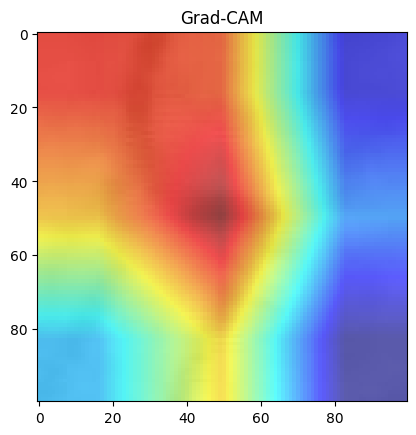

In [18]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()